# PCA, Skew Ratio, counts distribution

This analysis only considered barcodes count assigned to each guide.  

*FOCUSED SCREEN*;
*WITH UPDATED CBE DATA*
*NO MENINGES*

Kexin Dong

March 20, 2026

In [17]:
import numpy as np 
import pandas as pd
import os
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']
import re
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42   
mpl.rcParams['ps.fonttype'] = 42 
mpl.rcParams['text.usetex'] = False

from sklearn.decomposition import PCA
import seaborn as sns

In [18]:
fp = 'counts/focused'
ABE_BC_COUNTS = pd.read_csv(fp + '/FC_ABE_BC_COUNTS.txt', sep='\t')
CBE_BC_COUNTS = pd.read_csv(fp + '/FC_CBE_BC_COUNTS_new.txt', sep='\t')
ABE_EPO_COUNTS = pd.read_csv(fp + '/FC_ABE_EPO_COUNTS.txt', sep='\t')
CBE_EPO_COUNTS = pd.read_csv(fp + '/FC_CBE_EPO_COUNTS_new.txt', sep='\t')

In [19]:
ABE_BC_COUNTS = ABE_BC_COUNTS[ABE_BC_COUNTS.columns[2:]]
ABE_EPO_COUNTS = ABE_EPO_COUNTS[ABE_EPO_COUNTS.columns[2:]]
CBE_EPO_COUNTS = CBE_EPO_COUNTS[CBE_EPO_COUNTS.columns[2:]]
CBE_BC_COUNTS = CBE_BC_COUNTS[CBE_BC_COUNTS.columns[2:]]

In [20]:
ABE_BC_COUNTS

,lib,input,d5,d15-rep1,d15-rep2,d15-rep3,d15-rep4,d15-rep5,spleen1,spleen2,...,bm1,bm2,bm3,bm4,bm5,men1,men2,men3,men4,men5
0,3604.0,7590.0,9740.0,2905.0,335.0,1953.0,897.0,47.0,2676.0,6806.0,...,4626.0,677.0,5696.0,8075.0,9193.0,189.0,9928.0,599.0,2556.0,10.0
1,18935.0,11979.0,12492.0,38218.0,8043.0,20875.0,24244.0,566.0,9877.0,7621.0,...,2558.0,10021.0,14030.0,13184.0,6526.0,785.0,3639.0,2569.0,3401.0,3093.0
2,44200.0,24893.0,26740.0,159395.0,14552.0,17922.0,24984.0,1288.0,27594.0,20444.0,...,26270.0,2220.0,8740.0,12995.0,5394.0,112814.0,38552.0,81248.0,2512.0,18412.0
3,4691.0,6452.0,8321.0,28166.0,4822.0,7193.0,5613.0,63.0,2562.0,3899.0,...,1068.0,2299.0,62.0,341.0,1546.0,752.0,255.0,8469.0,6497.0,97730.0
4,15547.0,13045.0,15106.0,90114.0,4516.0,21661.0,8079.0,252.0,9388.0,13387.0,...,5088.0,24335.0,6931.0,25028.0,3867.0,481.0,40145.0,4544.0,1352.0,6775.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,51283.0,40323.0,49641.0,266685.0,36486.0,27248.0,76050.0,1107.0,36001.0,35266.0,...,82476.0,123863.0,4442.0,47190.0,4851.0,38375.0,22729.0,54721.0,25292.0,36717.0
372,29168.0,27303.0,35946.0,109799.0,13142.0,27212.0,26981.0,721.0,22663.0,26213.0,...,35798.0,97094.0,9731.0,22846.0,18715.0,11677.0,29545.0,51894.0,15496.0,21683.0
373,51625.0,50847.0,61386.0,340616.0,30955.0,18169.0,65875.0,1308.0,56724.0,41785.0,...,39083.0,4397.0,13708.0,33940.0,17456.0,27987.0,84385.0,383042.0,24419.0,61943.0
374,38285.0,37569.0,45677.0,185270.0,20286.0,56847.0,45879.0,685.0,58389.0,26677.0,...,17330.0,2143.0,2337.0,40502.0,23061.0,42583.0,12758.0,40747.0,58187.0,59043.0


In [21]:
ABE_EPO_COUNTS

,lib,input,d5,d15-rep1,d15-rep2,d15-rep3,d15-rep4,d15-rep5,spleen1,spleen2,...,bm1,bm2,bm3,bm4,bm5,men1,men2,men3,men4,men5
0,3604.0,7590.0,3417.0,6.0,1535.0,2523.0,184.0,33.0,4800.0,4456.0,...,7358.0,4098.0,1230.0,9038.0,14230.0,9640.0,4726.0,6538.0,1239.0,10384.0
1,18935.0,11979.0,21539.0,451.0,38580.0,41832.0,6563.0,4879.0,7848.0,15799.0,...,9289.0,5095.0,8046.0,5962.0,16375.0,17775.0,1296.0,38155.0,1397.0,2855.0
2,44200.0,24893.0,44670.0,1092.0,81078.0,107904.0,12790.0,7223.0,13168.0,7618.0,...,26193.0,3120.0,17765.0,12595.0,32601.0,30297.0,848.0,4657.0,5610.0,16731.0
3,4691.0,6452.0,20236.0,676.0,24128.0,41348.0,2841.0,2509.0,5706.0,8427.0,...,12940.0,716.0,12555.0,5107.0,20734.0,16853.0,4544.0,9143.0,1728.0,16727.0
4,15547.0,13045.0,31390.0,276.0,41479.0,88768.0,5330.0,2186.0,11753.0,20724.0,...,67251.0,24916.0,25309.0,7876.0,19670.0,36078.0,3057.0,14803.0,4916.0,3928.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
371,51283.0,40323.0,44701.0,896.0,71508.0,131940.0,7982.0,6604.0,11675.0,24642.0,...,20444.0,24177.0,14967.0,12461.0,33888.0,16762.0,29.0,1790.0,5218.0,5139.0
372,29168.0,27303.0,30533.0,291.0,35939.0,80548.0,3714.0,2996.0,12728.0,9788.0,...,25784.0,15393.0,12015.0,10634.0,19281.0,11809.0,5650.0,22973.0,5000.0,4047.0
373,51625.0,50847.0,46626.0,1031.0,102805.0,126612.0,14962.0,7781.0,16815.0,16172.0,...,61952.0,38543.0,55546.0,17269.0,54649.0,74329.0,1559.0,231208.0,9220.0,14513.0
374,38285.0,37569.0,36275.0,570.0,55678.0,92036.0,8298.0,4603.0,16721.0,27368.0,...,25972.0,32314.0,14364.0,6802.0,37102.0,18201.0,26116.0,3322.0,8344.0,13320.0


In [22]:
CBE_EPO_COUNTS

,lib,input,d5,d15-rep1,d15-rep2,d15-rep3,d15-rep4,d15-rep5,spleen1,spleen2,...,bm1,bm2,bm3,bm4,bm5,bm6,bm7,bm8,bm9,bm10
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,142.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4830.0,6522.0,12086.0,17482.0,6128.0,10143.0,14812.0,11261.0,4037.0,11015.0,...,7111.0,18900.0,5107.0,5806.0,3550.0,7162.0,48861.0,3206.0,18985.0,4613.0
2,3597.0,2544.0,4539.0,10485.0,2760.0,5153.0,8934.0,9902.0,683.0,6018.0,...,3959.0,17532.0,1471.0,2018.0,1799.0,5226.0,895.0,1282.0,1923.0,7765.0
3,3059.0,5192.0,1617.0,10081.0,4481.0,3476.0,3588.0,6643.0,3185.0,1312.0,...,108.0,2460.0,2509.0,2983.0,5193.0,2167.0,3910.0,0.0,1301.0,515.0
4,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,176.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1628,977.0,1359.0,3735.0,2051.0,331.0,1055.0,2983.0,1911.0,2185.0,754.0,...,1876.0,1.0,2886.0,1280.0,155.0,560.0,8.0,60.0,1808.0,56.0
1629,5756.0,10786.0,3931.0,12367.0,3169.0,3594.0,6091.0,14205.0,3052.0,5889.0,...,5984.0,4093.0,10964.0,12646.0,13477.0,3998.0,2106.0,2423.0,8798.0,5847.0
1630,6664.0,7917.0,11805.0,13464.0,1782.0,6463.0,10171.0,8650.0,7137.0,1754.0,...,12029.0,2.0,3742.0,10105.0,9359.0,2139.0,7838.0,411.0,4222.0,7869.0
1631,4266.0,1457.0,3202.0,6138.0,10.0,1814.0,4446.0,6121.0,922.0,810.0,...,2317.0,0.0,7215.0,2252.0,2274.0,67.0,196.0,1055.0,3296.0,7.0


In [23]:
CBE_BC_COUNTS

,lib,input,d5,d15-rep1,d15-rep2,d15-rep3,d15-rep4,d15-rep5,spleen1,spleen2,...,bm1,bm2,bm3,bm4,bm5,bm6,bm7,bm8,bm9,bm10
0,1.0,0.0,0.0,0.0,142.0,0.0,0.0,0.0,142.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4830.0,6522.0,4508.0,8760.0,6275.0,6660.0,7726.0,14844.0,7111.0,18900.0,...,728.0,11679.0,4396.0,20309.0,6832.0,2080.0,11397.0,1287.0,2261.0,11956.0
2,3597.0,2544.0,1657.0,4030.0,4191.0,2828.0,3598.0,6047.0,3959.0,17532.0,...,12342.0,136728.0,2676.0,4699.0,1363.0,2943.0,18675.0,1723.0,2784.0,4992.0
3,3059.0,5192.0,1883.0,4512.0,1638.0,5792.0,3408.0,5423.0,108.0,2460.0,...,1.0,1619.0,2994.0,2700.0,7740.0,325.0,2.0,0.0,13.0,0.0
4,8.0,0.0,1301.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1628,977.0,1359.0,1324.0,2153.0,1243.0,2117.0,2392.0,5156.0,1876.0,1.0,...,0.0,440.0,643.0,4078.0,41.0,2.0,1809.0,19044.0,491.0,1053.0
1629,5756.0,10786.0,4190.0,11195.0,8705.0,7088.0,7080.0,16750.0,5984.0,4093.0,...,3.0,9993.0,9184.0,70778.0,2368.0,727.0,4294.0,103.0,1389.0,36996.0
1630,6664.0,7917.0,6893.0,9322.0,6535.0,10487.0,8382.0,10346.0,12029.0,2.0,...,6166.0,3326.0,4557.0,4738.0,19255.0,12010.0,1290.0,5786.0,6496.0,8823.0
1631,4266.0,1457.0,769.0,5432.0,4214.0,4362.0,4483.0,3053.0,2317.0,0.0,...,2126.0,1678.0,11.0,21115.0,2687.0,0.0,3940.0,2.0,1.0,1.0


# PCA

OG figure 2 b-c


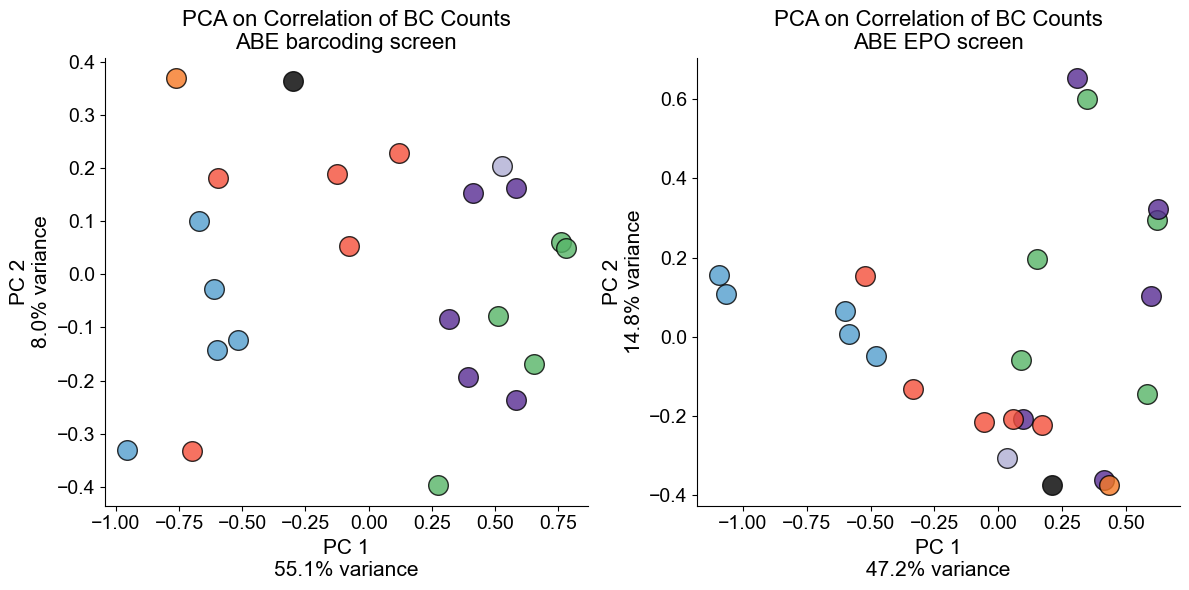

In [27]:
def pca_scatter(data, ax, title, palette):
    """
    data: dataframe to compute correlation and PCA
    ax: subplot axis
    title: subplot title
    palette: list of colors for each point
    """

    # PCA on correlation matrix
    pca = PCA(n_components=2)
    Xt = pca.fit_transform(data.corr(method='spearman'))

    # scatter points
    for i in range(len(Xt)):
        ax.scatter(
            Xt[i][0], Xt[i][1],
            edgecolor='black',
            s=200,
            alpha=.8,
            c=palette[i]
        )

    # explained variance
    var = pca.explained_variance_ratio_

    ax.set_xlabel(f'PC 1\n{np.round(var[0]*100, 1)}% variance', fontsize=15)
    ax.set_ylabel(f'PC 2\n{np.round(var[1]*100, 1)}% variance', fontsize=15)

    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_title(title, fontsize=16)

yellows = sns.color_palette('Oranges').as_hex()
blues   = sns.color_palette('Blues').as_hex()
greens  = sns.color_palette('Greens').as_hex()
reds    = sns.color_palette('Reds').as_hex()
purples = sns.color_palette('Purples').as_hex()

palette = [
    greens[3], greens[3], greens[3], greens[3], greens[3],   # bone marrow
    purples[5], purples[5], purples[5], purples[5], purples[5], # d15
    purples[2],             # d5
    yellows[3],             # input
    'black',                # plasmid
    reds[3], reds[3], reds[3], reds[3], reds[3],   # men
    blues[3], blues[3], blues[3], blues[3], blues[3] # spleen
]
fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False, sharey=False)
pca_scatter(ABE_BC_COUNTS,  axes[0], "PCA on Correlation of BC Counts\nABE barcoding screen", palette)
pca_scatter(ABE_EPO_COUNTS, axes[1], "PCA on Correlation of BC Counts\nABE EPO screen",      palette)

fig.tight_layout()
fig.savefig('figures_new_cbe/1_pca_abe.pdf')
plt.show()

In [28]:
CBE_EPO_COUNTS

,lib,input,d5,d15-rep1,d15-rep2,d15-rep3,d15-rep4,d15-rep5,spleen1,spleen2,...,bm1,bm2,bm3,bm4,bm5,bm6,bm7,bm8,bm9,bm10
0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,142.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4830.0,6522.0,12086.0,17482.0,6128.0,10143.0,14812.0,11261.0,4037.0,11015.0,...,7111.0,18900.0,5107.0,5806.0,3550.0,7162.0,48861.0,3206.0,18985.0,4613.0
2,3597.0,2544.0,4539.0,10485.0,2760.0,5153.0,8934.0,9902.0,683.0,6018.0,...,3959.0,17532.0,1471.0,2018.0,1799.0,5226.0,895.0,1282.0,1923.0,7765.0
3,3059.0,5192.0,1617.0,10081.0,4481.0,3476.0,3588.0,6643.0,3185.0,1312.0,...,108.0,2460.0,2509.0,2983.0,5193.0,2167.0,3910.0,0.0,1301.0,515.0
4,8.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,176.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1628,977.0,1359.0,3735.0,2051.0,331.0,1055.0,2983.0,1911.0,2185.0,754.0,...,1876.0,1.0,2886.0,1280.0,155.0,560.0,8.0,60.0,1808.0,56.0
1629,5756.0,10786.0,3931.0,12367.0,3169.0,3594.0,6091.0,14205.0,3052.0,5889.0,...,5984.0,4093.0,10964.0,12646.0,13477.0,3998.0,2106.0,2423.0,8798.0,5847.0
1630,6664.0,7917.0,11805.0,13464.0,1782.0,6463.0,10171.0,8650.0,7137.0,1754.0,...,12029.0,2.0,3742.0,10105.0,9359.0,2139.0,7838.0,411.0,4222.0,7869.0
1631,4266.0,1457.0,3202.0,6138.0,10.0,1814.0,4446.0,6121.0,922.0,810.0,...,2317.0,0.0,7215.0,2252.0,2274.0,67.0,196.0,1055.0,3296.0,7.0


In [29]:
CBE_BC_COUNTS

,lib,input,d5,d15-rep1,d15-rep2,d15-rep3,d15-rep4,d15-rep5,spleen1,spleen2,...,bm1,bm2,bm3,bm4,bm5,bm6,bm7,bm8,bm9,bm10
0,1.0,0.0,0.0,0.0,142.0,0.0,0.0,0.0,142.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4830.0,6522.0,4508.0,8760.0,6275.0,6660.0,7726.0,14844.0,7111.0,18900.0,...,728.0,11679.0,4396.0,20309.0,6832.0,2080.0,11397.0,1287.0,2261.0,11956.0
2,3597.0,2544.0,1657.0,4030.0,4191.0,2828.0,3598.0,6047.0,3959.0,17532.0,...,12342.0,136728.0,2676.0,4699.0,1363.0,2943.0,18675.0,1723.0,2784.0,4992.0
3,3059.0,5192.0,1883.0,4512.0,1638.0,5792.0,3408.0,5423.0,108.0,2460.0,...,1.0,1619.0,2994.0,2700.0,7740.0,325.0,2.0,0.0,13.0,0.0
4,8.0,0.0,1301.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1628,977.0,1359.0,1324.0,2153.0,1243.0,2117.0,2392.0,5156.0,1876.0,1.0,...,0.0,440.0,643.0,4078.0,41.0,2.0,1809.0,19044.0,491.0,1053.0
1629,5756.0,10786.0,4190.0,11195.0,8705.0,7088.0,7080.0,16750.0,5984.0,4093.0,...,3.0,9993.0,9184.0,70778.0,2368.0,727.0,4294.0,103.0,1389.0,36996.0
1630,6664.0,7917.0,6893.0,9322.0,6535.0,10487.0,8382.0,10346.0,12029.0,2.0,...,6166.0,3326.0,4557.0,4738.0,19255.0,12010.0,1290.0,5786.0,6496.0,8823.0
1631,4266.0,1457.0,769.0,5432.0,4214.0,4362.0,4483.0,3053.0,2317.0,0.0,...,2126.0,1678.0,11.0,21115.0,2687.0,0.0,3940.0,2.0,1.0,1.0


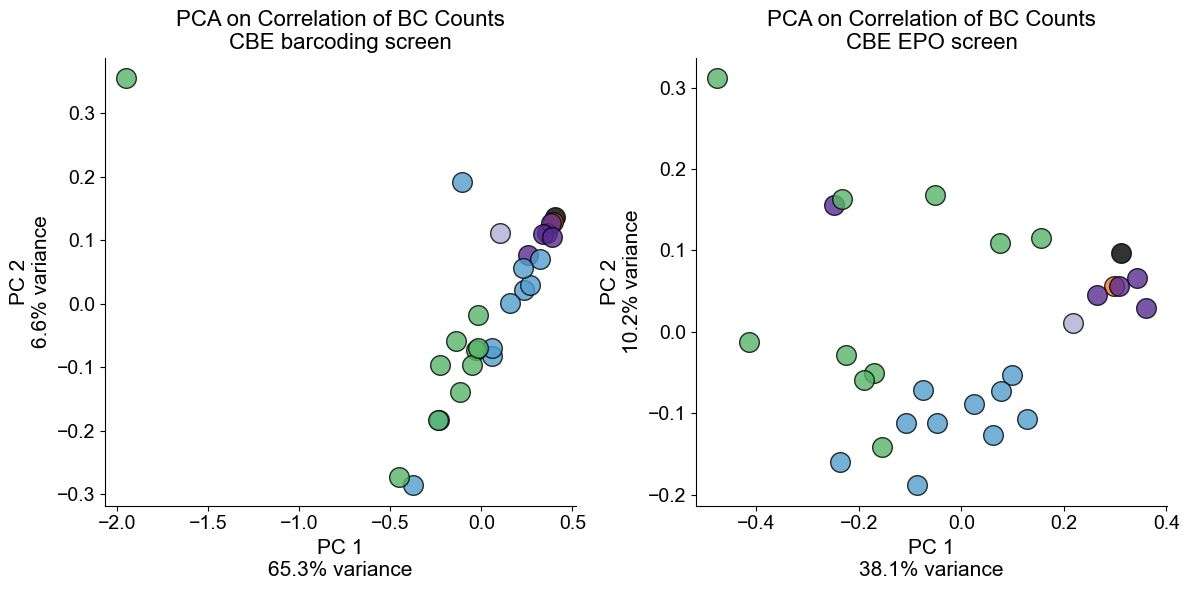

In [34]:
palette_1 = [
    'black', # plasmid
    yellows[3], # input 
    purples[2], # d5
    purples[5], purples[5], purples[5], purples[5], purples[5], # d15
    blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3], blues[3],# spleen
    greens[3], greens[3], greens[3],greens[3], greens[3], greens[3],greens[3], greens[3], greens[3],greens[3],   # bone marrow
]
palette_2 = palette_1

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=False, sharey=False)

pca_scatter(CBE_BC_COUNTS,  axes[0], "PCA on Correlation of BC Counts\nCBE barcoding screen", palette_1)
pca_scatter(CBE_EPO_COUNTS, axes[1], "PCA on Correlation of BC Counts\nCBE EPO screen",      palette_2)
fig.tight_layout()
fig.savefig('figures_new_cbe/2_pca_cbe.pdf')

plt.show()

# Skew Ratio

OG figure 2 d


In [31]:
ABE_BC_samps = list(ABE_BC_COUNTS.columns)
ABE_EPO_samps = list(ABE_EPO_COUNTS.columns)

BC_skew = []
EPO_skew = []
for i in ABE_BC_samps:
    d = sorted(np.asarray(ABE_BC_COUNTS[i]))
    ten = int(.1*len(d))
    ninety = int(.9*len(d))
    if d[ten]>0:
        BC_skew.append(d[ninety]/d[ten])
    else:
        BC_skew.append(d[ninety])

for i in ABE_EPO_samps:
    d = sorted(np.asarray(ABE_EPO_COUNTS[i]))
    ten = int(.1*len(d))
    ninety = int(.9*len(d))
    if d[ten]>0:
        EPO_skew.append(d[ninety]/d[ten])
    else:
        EPO_skew.append(d[ninety])

BC_skew_df = pd.DataFrame(dict(zip(['Sample', '90/10 Skew Ratio'], [ABE_BC_samps, BC_skew])))
EPO_skew_df = pd.DataFrame(dict(zip(['Sample', '90/10 Skew Ratio'], [ABE_EPO_samps, EPO_skew])))

In [32]:
ABE_BC_COUNTS.columns

Index(['lib', 'input', 'd5', 'd15-rep1', 'd15-rep2', 'd15-rep3', 'd15-rep4',
       'd15-rep5', 'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5',
       'bm1', 'bm2', 'bm3', 'bm4', 'bm5', 'men1', 'men2', 'men3', 'men4',
       'men5'],
      dtype='object')

In [33]:
BC_skew_df

,Sample,90/10 Skew Ratio
0,lib,3.610216
1,input,4.676304
2,d5,4.653696
3,d15-rep1,6.337104
4,d15-rep2,9.270740
5,d15-rep3,8.998569
6,d15-rep4,7.521183
7,d15-rep5,7.750000
8,spleen1,11.073970
9,spleen2,6.350638


/var/folders/rl/65f1zcd575n092yn3xlqlqfw0000gn/T/ipykernel_60724/675044183.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = BC_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order)
/var/folders/rl/65f1zcd575n092yn3xlqlqfw0000gn/T/ipykernel_60724/675044183.py:63: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = EPO_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette,order=order)
/var/folders/rl/65f1zcd575n092yn3xlqlqfw0000gn/T/ipykernel_60724/675044183.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assig

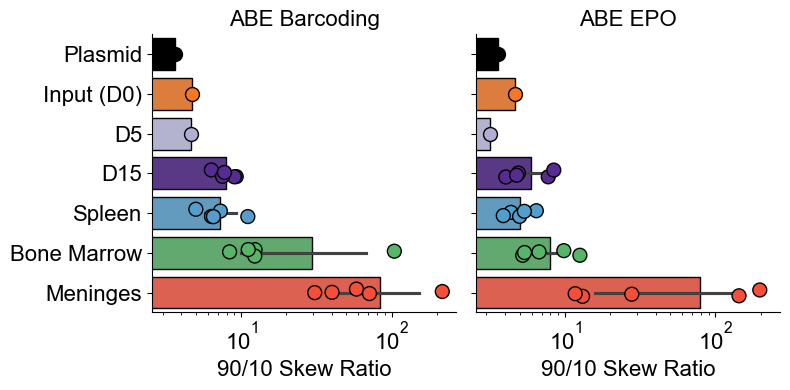

In [35]:

ax_dict_BC = dict(
    zip(['bm1', 'bm2', 'bm3', 'bm4', 'bm5', 
        'd15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5', 
        'd5',
        'input',
        'lib',
        'men1', 'men2', 'men3','men4', 'men5', 
        'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5'], 
       [5,5,5,5,5,
        3,3,3,3,3,
        2,
        1,
        0,
        6,6,6,6,6,
        4,4,4,4,4]))

ax_dict_EPO = dict(
    zip(['bm1', 'bm2', 'bm3', 'bm4', 'bm5', 
                        'd15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5', 
                        'd5',
                        'input',
                        'lib',
                        'men1', 'men2', 'men3','men4', 'men5', 
                        'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5'], 
       [5,5,5,5,5,
        3,3,3,3,3,
        2,
        1,
        0,
        6,6,6,6,6,
        4,4,4,4,4]))

d2 = dict(zip([0,1,2,3,4,5,6],['Plasmid', 'Input (D0)','D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']))

BC_name = []
EPO_name = []
for i, val in BC_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict_EPO[s]
    s3 = d2[s2]
    BC_name.append(s3)

for i, val in EPO_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict_EPO[s]
    s3 = d2[s2]
    EPO_name.append(s3)

BC_skew_df['Name'] = BC_name
EPO_skew_df['Name'] = EPO_name

fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True, sharex=True)

blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = ['black', yellows[3], purples[2], purples[5], blues[3], greens[3], reds[3]]
order=['Plasmid', 'Input (D0)', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']

sns.barplot(data = BC_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order)
sns.barplot(data = EPO_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette,order=order)

sns.stripplot(data = BC_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
sns.stripplot(data = EPO_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[0].set_ylabel('')
ax[1].set_ylabel('')

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_title('ABE Barcoding', fontsize=16)
ax[1].set_title('ABE EPO', fontsize=16)
ax[0].set_xlabel('90/10 Skew Ratio', fontsize=16)
ax[1].set_xlabel('90/10 Skew Ratio', fontsize=16)
fig.tight_layout()
plt.savefig('figures_new_cbe/3_skew_abe.pdf')

In [36]:
CBE_BC_samps = list(CBE_BC_COUNTS.columns)
CBE_EPO_samps = list(CBE_EPO_COUNTS.columns)

BC_skew = []
EPO_skew = []
for i in CBE_BC_samps:
    d = sorted(np.asarray(CBE_BC_COUNTS[i]))
    ten = int(.1*len(d))
    ninety = int(.9*len(d))
    if d[ten]>0:
        BC_skew.append(d[ninety]/d[ten])
    else:
        BC_skew.append(d[ninety])

for i in CBE_EPO_samps:
    d = sorted(np.asarray(CBE_EPO_COUNTS[i]))
    ten = int(.1*len(d))
    ninety = int(.9*len(d))
    if d[ten]>0:
        EPO_skew.append(d[ninety]/d[ten])
    else:
        EPO_skew.append(d[ninety])

BC_skew_df = pd.DataFrame(dict(zip(['Sample', '90/10 Skew Ratio'], [CBE_BC_samps, BC_skew])))
EPO_skew_df = pd.DataFrame(dict(zip(['Sample', '90/10 Skew Ratio'], [CBE_EPO_samps, EPO_skew])))

In [40]:
BC_skew_df

,Sample,90/10 Skew Ratio,Name
0,lib,5880.0,Plasmid
1,input,8016.0,Input (D0)
2,d5,5183.0,D5
3,d15-rep1,11084.0,D15
4,d15-rep2,7719.0,D15
5,d15-rep3,9989.0,D15
6,d15-rep4,9466.0,D15
7,d15-rep5,11665.0,D15
8,spleen1,19726.0,Spleen
9,spleen2,14335.0,Spleen


In [37]:
ax_dict = dict(
    zip(['bm1', 'bm2', 'bm3', 'bm4', 'bm5', 'bm6', 'bm7', 'bm8', 'bm9', 'bm10',
        'd15-rep1', 'd15-rep2', 'd15-rep3','d15-rep4', 'd15-rep5', 
        'd5', 
        'input',
        'lib',
        'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5', 'spleen6', 'spleen7', 'spleen8', 'spleen9', 'spleen10'], 
       [5,5,5,5,5,5,5,5,5,5,
        3,3,3,3,3,
        2,
        1,
        0,
        4,4,4,4,4,4,4,4,4,4]))

d2 = dict(zip([0,1,2,3,4,5,6],['Plasmid', 'Input (D0)','D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']))

BC_name = []
EPO_name = []
for i, val in BC_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict[s]
    s3 = d2[s2]
    BC_name.append(s3)

for i, val in EPO_skew_df.iterrows():
    s = val['Sample']
    s2 = ax_dict[s]
    s3 = d2[s2]
    EPO_name.append(s3)

BC_skew_df['Name'] = BC_name
EPO_skew_df['Name'] = EPO_name

/var/folders/rl/65f1zcd575n092yn3xlqlqfw0000gn/T/ipykernel_60724/4042603714.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = BC_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order)
/var/folders/rl/65f1zcd575n092yn3xlqlqfw0000gn/T/ipykernel_60724/4042603714.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data = EPO_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette,order=order)
/var/folders/rl/65f1zcd575n092yn3xlqlqfw0000gn/T/ipykernel_60724/4042603714.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. As

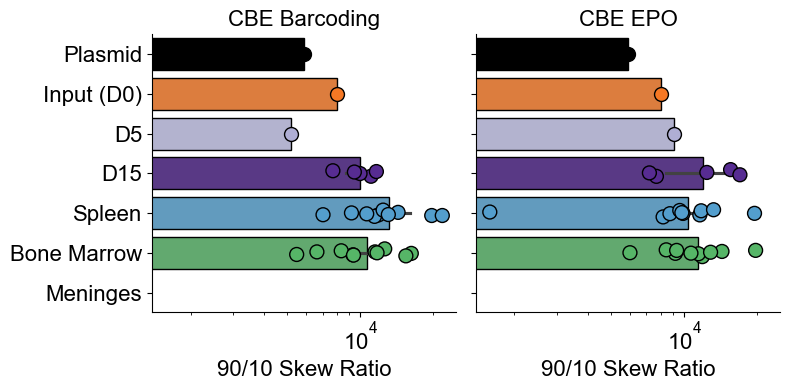

In [38]:

fig, ax = plt.subplots(1,2, figsize=(8,4), sharey=True, sharex=True)

blues = blues.as_hex()
greens = greens.as_hex()
reds = reds.as_hex()
yellows = yellows.as_hex()

palette = ['black', yellows[3], purples[2], purples[5], blues[3], greens[3], reds[3]]
order=['Plasmid', 'Input (D0)', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']

sns.barplot(data = BC_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order)
sns.barplot(data = EPO_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette,order=order)

sns.stripplot(data = BC_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[0], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
sns.stripplot(data = EPO_skew_df, y='Name', x='90/10 Skew Ratio', ax=ax[1], edgecolor='black', linewidth=1, palette = palette, order=order, s=10)
ax[0].set_xscale('log')
ax[1].set_xscale('log')
ax[0].set_ylabel('')
ax[1].set_ylabel('')

ax[0].spines[['top', 'right']].set_visible(False)
ax[0].tick_params(axis='both', which='major', labelsize=16,)
ax[1].spines[['top', 'right']].set_visible(False)
ax[1].tick_params(axis='both', which='major', labelsize=16,)
ax[0].set_title('CBE Barcoding', fontsize=16)
ax[1].set_title('CBE EPO', fontsize=16)
ax[0].set_xlabel('90/10 Skew Ratio', fontsize=16)
ax[1].set_xlabel('90/10 Skew Ratio', fontsize=16)

fig.tight_layout()
plt.savefig('figures_new_cbe/4_skew_cbe.pdf')

In [ ]:
def ecdf(a):
    a = np.asarray(a)
    a = a[~pd.isna(a)]
    x, counts = np.unique(a, return_counts=True)
    cusum = np.cumsum(counts)
    return x, cusum / cusum[-1]

In [50]:
def get_sample_cols(df):
    return [c for c in df.columns if c not in ['sgRNA', 'gene', 'Guide_ID']]


def plot_count_cdf_by_group(df, ax, ax_dict, d2, palette, order, title):
    sample_cols = get_sample_cols(df)

    for s in sample_cols:
        if s not in ax_dict:
            continue

        vals = pd.to_numeric(df[s], errors='coerce').dropna()
        x, y = ecdf(vals)

        group_id = ax_dict[s]
        group_name = d2[group_id]
        color = palette[group_id]

        ax.plot(
            x, y,
            linewidth=2.5,
            alpha=0.75,
            c=color,
            label=group_name
        )

    ax.spines[['top', 'right']].set_visible(False)
    ax.tick_params(axis='both', which='major', labelsize=16)
    ax.set_ylabel('CDF(Counts)', fontsize=13)
    ax.set_title(title, fontsize=14)
    ax.grid(alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()
    seen = set()
    uniq_handles = []
    uniq_labels = []
    for h, l in zip(handles, labels):
        if l in order and l not in seen:
            uniq_handles.append(h)
            uniq_labels.append(l)
            seen.add(l)

    ordered_handles = []
    ordered_labels = []
    for g in order:
        if g in uniq_labels:
            idx = uniq_labels.index(g)
            ordered_handles.append(uniq_handles[idx])
            ordered_labels.append(uniq_labels[idx])

    ax.legend(ordered_handles, ordered_labels, fontsize=12, loc='lower right', frameon=False)


In [51]:
ax_dict_BC = dict(
    zip(
        ['bm1', 'bm2', 'bm3', 'bm4', 'bm5',
         'd15-rep1', 'd15-rep2', 'd15-rep3', 'd15-rep4', 'd15-rep5',
         'd5',
         'input',
         'lib',
         'men1', 'men2', 'men3', 'men4', 'men5',
         'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5'],
        [5, 5, 5, 5, 5,
         3, 3, 3, 3, 3,
         2,
         1,
         0,
         6, 6, 6, 6, 6,
         4, 4, 4, 4, 4]
    )
)

ax_dict_EPO = dict(
    zip(
        ['bm1', 'bm2', 'bm3', 'bm4', 'bm5',
         'd15-rep1', 'd15-rep2', 'd15-rep3', 'd15-rep4', 'd15-rep5',
         'd5',
         'input',
         'lib',
         'men1', 'men2', 'men3', 'men4', 'men5',
         'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5'],
        [5, 5, 5, 5, 5,
         3, 3, 3, 3, 3,
         2,
         1,
         0,
         6, 6, 6, 6, 6,
         4, 4, 4, 4, 4]
    )
)

d2 = dict(zip([0, 1, 2, 3, 4, 5, 6],
              ['Plasmid', 'Input (D0)', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']))

palette = ['black', yellows[3], purples[2], purples[5], blues[3], greens[3], reds[3]]
order = ['Plasmid', 'Input (D0)', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']

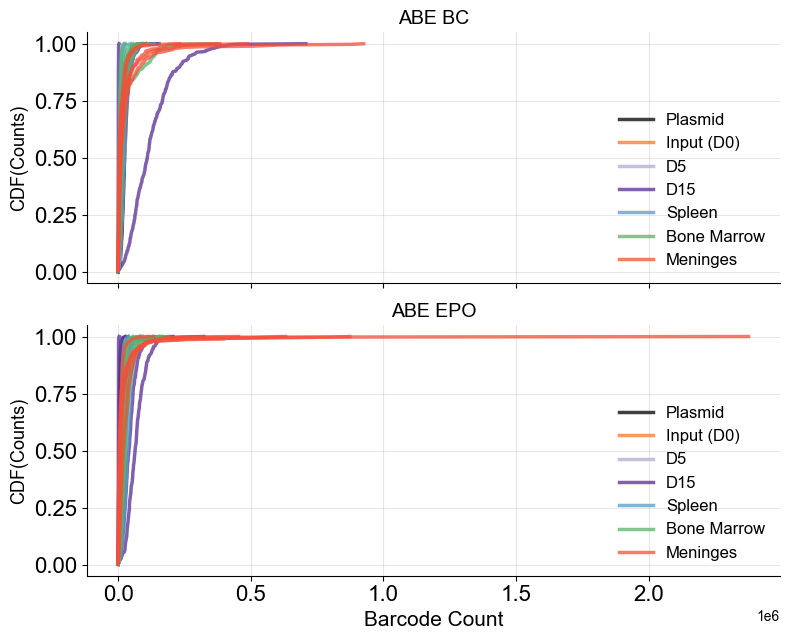

In [53]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True, sharey=True)

plot_count_cdf_by_group(
    ABE_BC_COUNTS, ax[0],
    ax_dict_BC, d2, palette, order,
    'ABE BC'
)

plot_count_cdf_by_group(
    ABE_EPO_COUNTS, ax[1],
    ax_dict_EPO, d2, palette, order,
    'ABE EPO'
)

ax[1].set_xlabel('Barcode Count', fontsize=15)

fig.tight_layout()
fig.savefig('figures_new_cbe/4_1_ABE_counts_cdf.pdf')
plt.show()

In [54]:
ax_dict = dict(
    zip(
        ['bm1', 'bm2', 'bm3', 'bm4', 'bm5', 'bm6', 'bm7', 'bm8', 'bm9', 'bm10',
         'd15-rep1', 'd15-rep2', 'd15-rep3', 'd15-rep4', 'd15-rep5',
         'd5',
         'input',
         'lib',
         'spleen1', 'spleen2', 'spleen3', 'spleen4', 'spleen5',
         'spleen6', 'spleen7', 'spleen8', 'spleen9', 'spleen10'],
        [5, 5, 5, 5, 5, 5, 5, 5, 5, 5,
         3, 3, 3, 3, 3,
         2,
         1,
         0,
         4, 4, 4, 4, 4, 4, 4, 4, 4, 4]
    )
)

d2 = dict(zip([0, 1, 2, 3, 4, 5, 6],
              ['Plasmid', 'Input (D0)', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']))

palette = ['black', yellows[3], purples[2], purples[5], blues[3], greens[3], reds[3]]
order = ['Plasmid', 'Input (D0)', 'D5', 'D15', 'Spleen', 'Bone Marrow', 'Meninges']


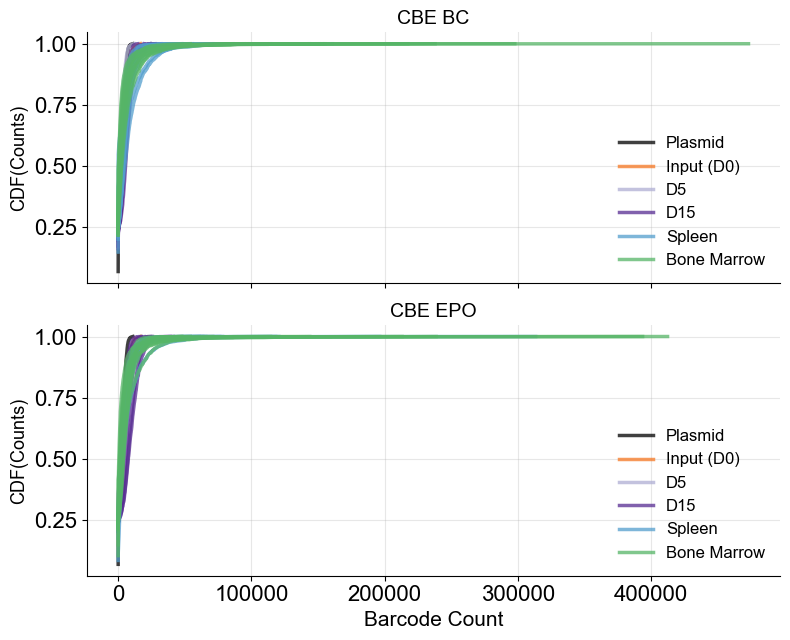

In [55]:
fig, ax = plt.subplots(2, 1, figsize=(8, 6.5), sharex=True, sharey=True)

plot_count_cdf_by_group(
    CBE_BC_COUNTS, ax[0],
    ax_dict, d2, palette, order,
    'CBE BC'
)

plot_count_cdf_by_group(
    CBE_EPO_COUNTS, ax[1],
    ax_dict, d2, palette, order,
    'CBE EPO'
)

ax[1].set_xlabel('Barcode Count', fontsize=15)

fig.tight_layout()
fig.savefig('figures_new_cbe/4_2_CBE_counts_cdf.pdf')
plt.show()

## Skew ratio seems sucks

# Histogram of gRNA counts for individual samples from the four subpools of the validation screen.

#### NEED TO RERUN #####
OG extended figure 4 a-b

In [57]:
CBE_EPO_COUNTS

,lib,input-rep1,input-rep2,input-rep3,input-rep4,input-rep5,d5-rep1,d5-rep2,d5-rep3,d5-rep4,...,bm1,bm2,bm3,bm4,bm5,men1,men2,men3,men4,men5
0,35.0,19730.0,23099.0,19741.0,14801.0,20380.0,13529.0,16467.0,11835.0,15561.0,...,3588.0,1907.0,1993.0,15772.0,3.0,89.0,10.0,251.0,51.0,2568.0
1,17.0,5688.0,7565.0,6805.0,4448.0,4599.0,6197.0,8119.0,8350.0,8666.0,...,10072.0,1294.0,2601.0,5762.0,20957.0,3.0,0.0,139.0,954.0,377.0
2,5.0,7369.0,7919.0,6072.0,4681.0,6819.0,3716.0,4945.0,4208.0,4884.0,...,2433.0,102.0,0.0,184.0,126.0,0.0,1.0,1.0,8.0,614.0
3,40.0,10765.0,19651.0,10955.0,9146.0,13182.0,7408.0,9925.0,11128.0,12285.0,...,99.0,217.0,2.0,21296.0,7.0,2.0,2.0,2.0,9.0,8.0
4,6.0,1267.0,2270.0,1160.0,777.0,1305.0,642.0,1477.0,209.0,1287.0,...,1.0,0.0,0.0,0.0,169.0,1.0,0.0,0.0,0.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1252,13.0,3255.0,6879.0,4402.0,3975.0,2556.0,2806.0,4640.0,4395.0,7956.0,...,23.0,2528.0,0.0,767.0,0.0,0.0,3.0,0.0,9.0,20.0
1253,59.0,12952.0,19382.0,13816.0,12686.0,14593.0,8614.0,12312.0,7812.0,9719.0,...,17298.0,13230.0,1655.0,45047.0,12.0,178.0,3028233.0,666.0,187.0,89.0
1254,74.0,14792.0,23716.0,15686.0,14213.0,19475.0,10660.0,13033.0,10363.0,12181.0,...,26612.0,10967.0,137.0,22008.0,475.0,102.0,2.0,2609.0,3681662.0,14.0
1255,8.0,4559.0,7452.0,4968.0,2326.0,4789.0,3554.0,4314.0,2811.0,4312.0,...,9.0,3.0,149.0,4356.0,1.0,50.0,1.0,317.0,51891.0,405.0


In [58]:
CBE_EPO_COUNTS

,lib,input-rep1,input-rep2,input-rep3,input-rep4,input-rep5,d5-rep1,d5-rep2,d5-rep3,d5-rep4,...,bm1,bm2,bm3,bm4,bm5,men1,men2,men3,men4,men5
0,35.0,19730.0,23099.0,19741.0,14801.0,20380.0,13529.0,16467.0,11835.0,15561.0,...,3588.0,1907.0,1993.0,15772.0,3.0,89.0,10.0,251.0,51.0,2568.0
1,17.0,5688.0,7565.0,6805.0,4448.0,4599.0,6197.0,8119.0,8350.0,8666.0,...,10072.0,1294.0,2601.0,5762.0,20957.0,3.0,0.0,139.0,954.0,377.0
2,5.0,7369.0,7919.0,6072.0,4681.0,6819.0,3716.0,4945.0,4208.0,4884.0,...,2433.0,102.0,0.0,184.0,126.0,0.0,1.0,1.0,8.0,614.0
3,40.0,10765.0,19651.0,10955.0,9146.0,13182.0,7408.0,9925.0,11128.0,12285.0,...,99.0,217.0,2.0,21296.0,7.0,2.0,2.0,2.0,9.0,8.0
4,6.0,1267.0,2270.0,1160.0,777.0,1305.0,642.0,1477.0,209.0,1287.0,...,1.0,0.0,0.0,0.0,169.0,1.0,0.0,0.0,0.0,11.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1252,13.0,3255.0,6879.0,4402.0,3975.0,2556.0,2806.0,4640.0,4395.0,7956.0,...,23.0,2528.0,0.0,767.0,0.0,0.0,3.0,0.0,9.0,20.0
1253,59.0,12952.0,19382.0,13816.0,12686.0,14593.0,8614.0,12312.0,7812.0,9719.0,...,17298.0,13230.0,1655.0,45047.0,12.0,178.0,3028233.0,666.0,187.0,89.0
1254,74.0,14792.0,23716.0,15686.0,14213.0,19475.0,10660.0,13033.0,10363.0,12181.0,...,26612.0,10967.0,137.0,22008.0,475.0,102.0,2.0,2609.0,3681662.0,14.0
1255,8.0,4559.0,7452.0,4968.0,2326.0,4789.0,3554.0,4314.0,2811.0,4312.0,...,9.0,3.0,149.0,4356.0,1.0,50.0,1.0,317.0,51891.0,405.0


In [59]:
list(ABE_BC_COUNTS.columns)

['lib',
 'input',
 'd5',
 'd15-rep1',
 'd15-rep2',
 'd15-rep3',
 'd15-rep4',
 'd15-rep5',
 'spleen1',
 'spleen2',
 'spleen3',
 'spleen4',
 'spleen5',
 'bm1',
 'bm2',
 'bm3',
 'bm4',
 'bm5',
 'men1',
 'men2',
 'men3',
 'men4',
 'men5']

In [60]:
NAMES_ABE_BC = NAMES_ABE_EPO = [
    'Plasmid','Input (D0)',
    'D5',
    'D15 REP1','D15 REP2','D15 REP3','D15 REP4','D15 REP5',
    'S1','S2','S3','S4','S5',
    'BM1','BM2','BM3','BM4','BM5',
    'M1','M2','M3','M4','M5'
]
DICT_ABE_BC = DICT_ABE_EPO = dict(zip(list(ABE_BC_COUNTS.columns), NAMES_ABE_BC))

In [61]:
NAMES_CBE_BC  = [
    'Plasmid',
    'Input REP1','Input REP2','Input REP3','Input REP4','Input REP5',
    'D5 REP1','D5 REP2','D5 REP3','D5 REP4','D5 REP5',
    'D15 REP1','D15 REP2','D15 REP3','D15 REP4','D15 REP5',
    'S1','S2','S4',
    'BM1','BM2','BM4',
    'M1','M2','M4'
]
NAMES_CBE_EPO = [
    'Plasmid',
    'Input REP1','Input REP2','Input REP3','Input REP4','Input REP5',
    'D5 REP1','D5 REP2','D5 REP3','D5 REP4','D5 REP5',
    'D15 REP1','D15 REP2','D15 REP3','D15 REP4','D15 REP5',
    'S1','S2','S3','S4','S5',
    'BM1','BM2','BM3','BM4','BM5',
    'M1','M2','M3','M4','M5'
]
DICT_CBE_BC =  dict(zip(list(CBE_BC_COUNTS.columns), NAMES_CBE_BC))
DICT_CBE_EPO = dict(zip(list(CBE_EPO_COUNTS.columns), NAMES_CBE_EPO))

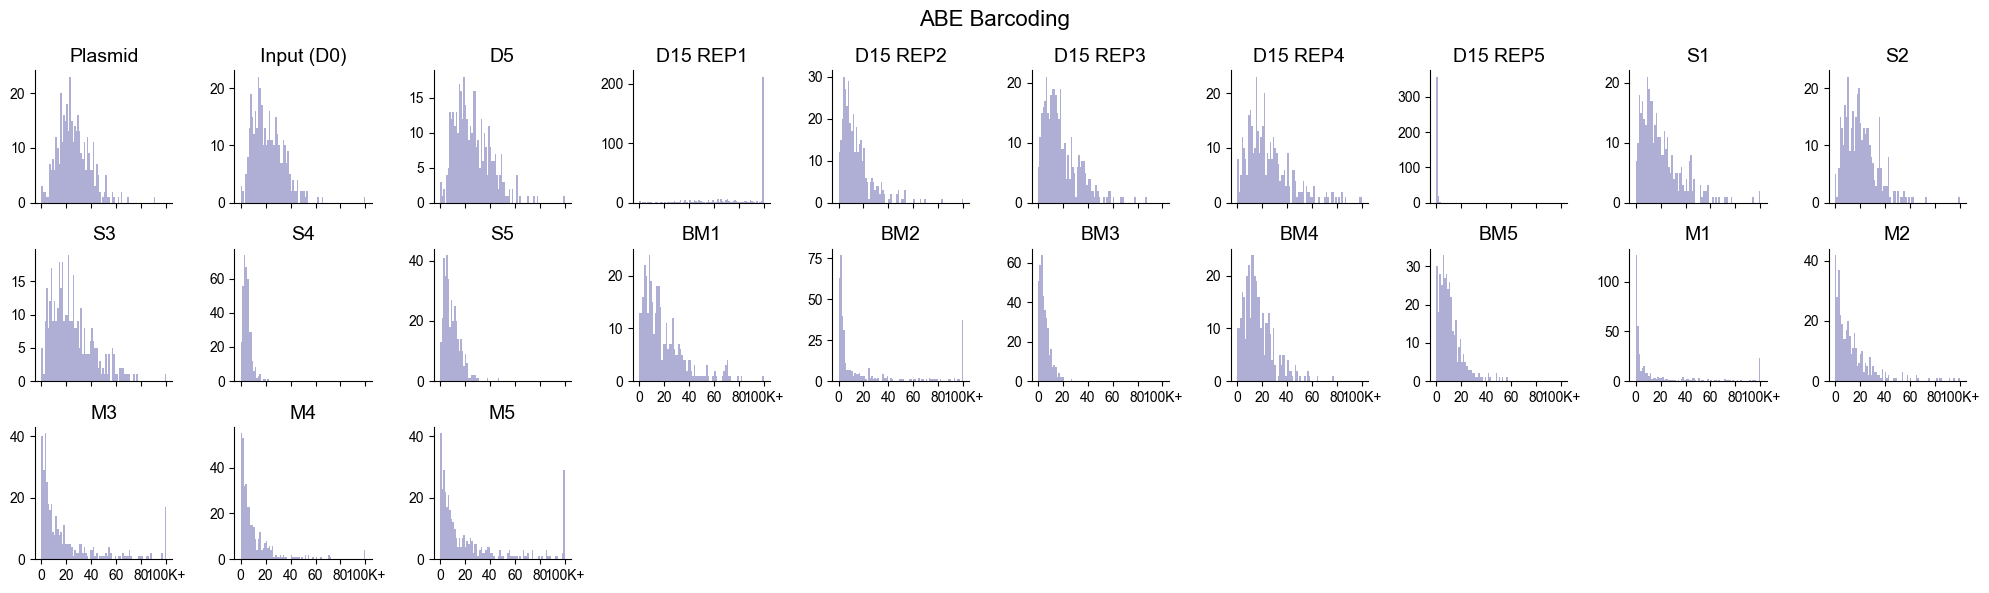

In [62]:
fig, ax = plt.subplots(3,10,figsize=(20,6), sharey=False, sharex=True)

for i in range(3):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(ABE_BC_COUNTS.columns):
            samp = list(ABE_BC_COUNTS.columns)[num_samp]
            bins=np.linspace(0,100000, 81)
            ax[i][k].hist(np.clip(ABE_BC_COUNTS[samp], bins[0], bins[-1]), bins=bins,color=purples[2], edgecolor='black', linewidth=0, density=False)
            ax[i][k].set_title(DICT_ABE_BC[samp], fontsize=14)
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].set_xticks([20000*x for x in [0,1,2,3,4,5]])
            ax[i][k].set_xticklabels([
                '0',
                '20',
                '40',
                '60',
                '80',
                '100K+'
            ])
            #ax.hist[]

for i in range(3,10):
    fig.delaxes(ax[2][i])
    ax[1][i].tick_params(labelbottom=True)

fig.suptitle('ABE Barcoding', fontsize=16)
fig.tight_layout()
fig.savefig('figures/hiost_abe_bc.pdf')

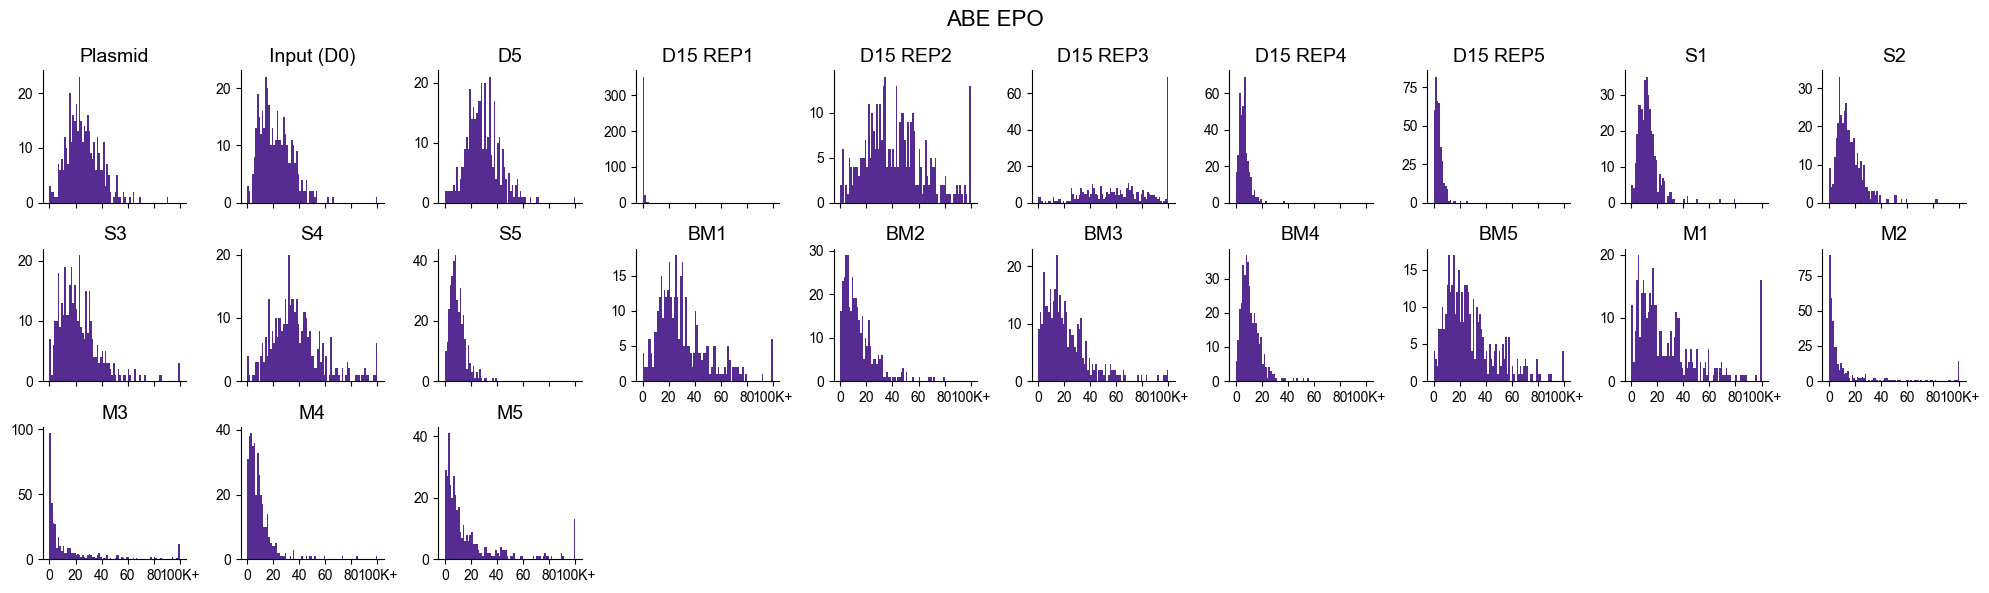

In [63]:
fig, ax = plt.subplots(3,10,figsize=(20,6), sharey=False, sharex=True)

for i in range(3):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(ABE_EPO_COUNTS.columns):
            samp = list(ABE_EPO_COUNTS.columns)[num_samp]
            bins=np.linspace(0,100000, 81)
            ax[i][k].hist(np.clip(ABE_EPO_COUNTS[samp], bins[0], bins[-1]), bins=bins,color=purples[5], edgecolor='black', linewidth=0, density=False)
            ax[i][k].set_title(DICT_ABE_EPO[samp], fontsize=14)
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].set_xticks([20000*x for x in [0,1,2,3,4,5]])
            ax[i][k].set_xticklabels([
                '0',
                '20',
                '40',
                '60',
                '80',
                '100K+'
            ])
            #ax.hist[]

for i in range(3,10):
    fig.delaxes(ax[2][i])
    ax[1][i].tick_params(labelbottom=True)

fig.suptitle('ABE EPO', fontsize=16)
fig.tight_layout()
fig.savefig('figures/hist_abe_epo.pdf')

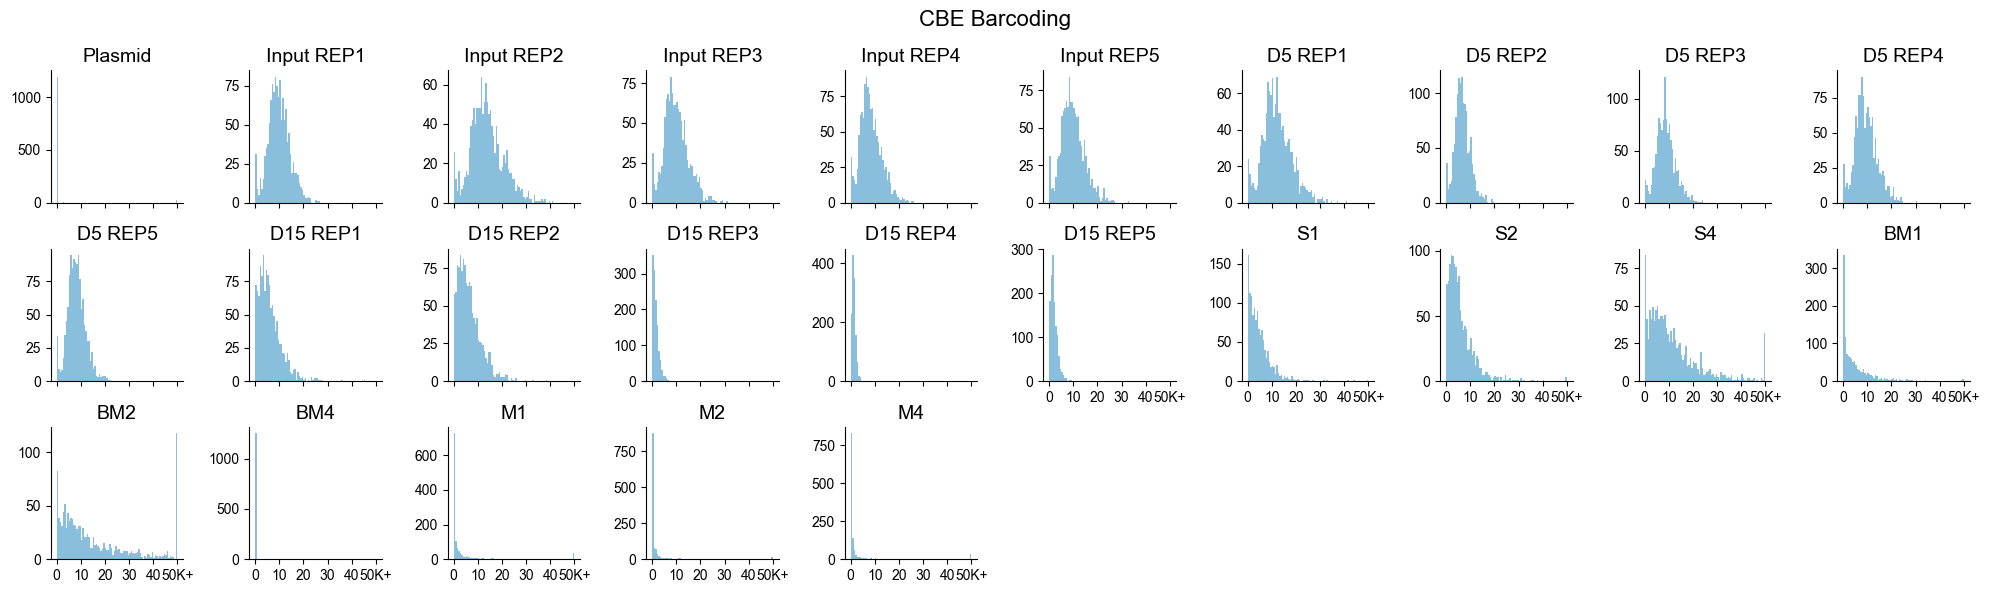

In [64]:
fig, ax = plt.subplots(3,10,figsize=(20,6), sharey=False, sharex=True)

for i in range(3):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(CBE_BC_COUNTS.columns):
            samp = list(CBE_BC_COUNTS.columns)[num_samp]
            bins=np.linspace(0,50000, 81)
            ax[i][k].hist(np.clip(CBE_BC_COUNTS[samp], bins[0], bins[-1]), bins=bins,color=blues[2], edgecolor='black', linewidth=0, density=False)
            ax[i][k].set_title(DICT_CBE_BC[samp], fontsize=14)
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].set_xticks([10000*x for x in [0,1,2,3,4,5]])
            ax[i][k].set_xticklabels([
                '0',
                '10',
                '20',
                '30',
                '40',
                '50K+'
            ])
            #ax.hist[]

for i in range(5,10):
    fig.delaxes(ax[2][i])
    ax[1][i].tick_params(labelbottom=True)

fig.suptitle('CBE Barcoding', fontsize=16)
fig.tight_layout()
fig.savefig('figures/hist_cbe_bc.pdf')

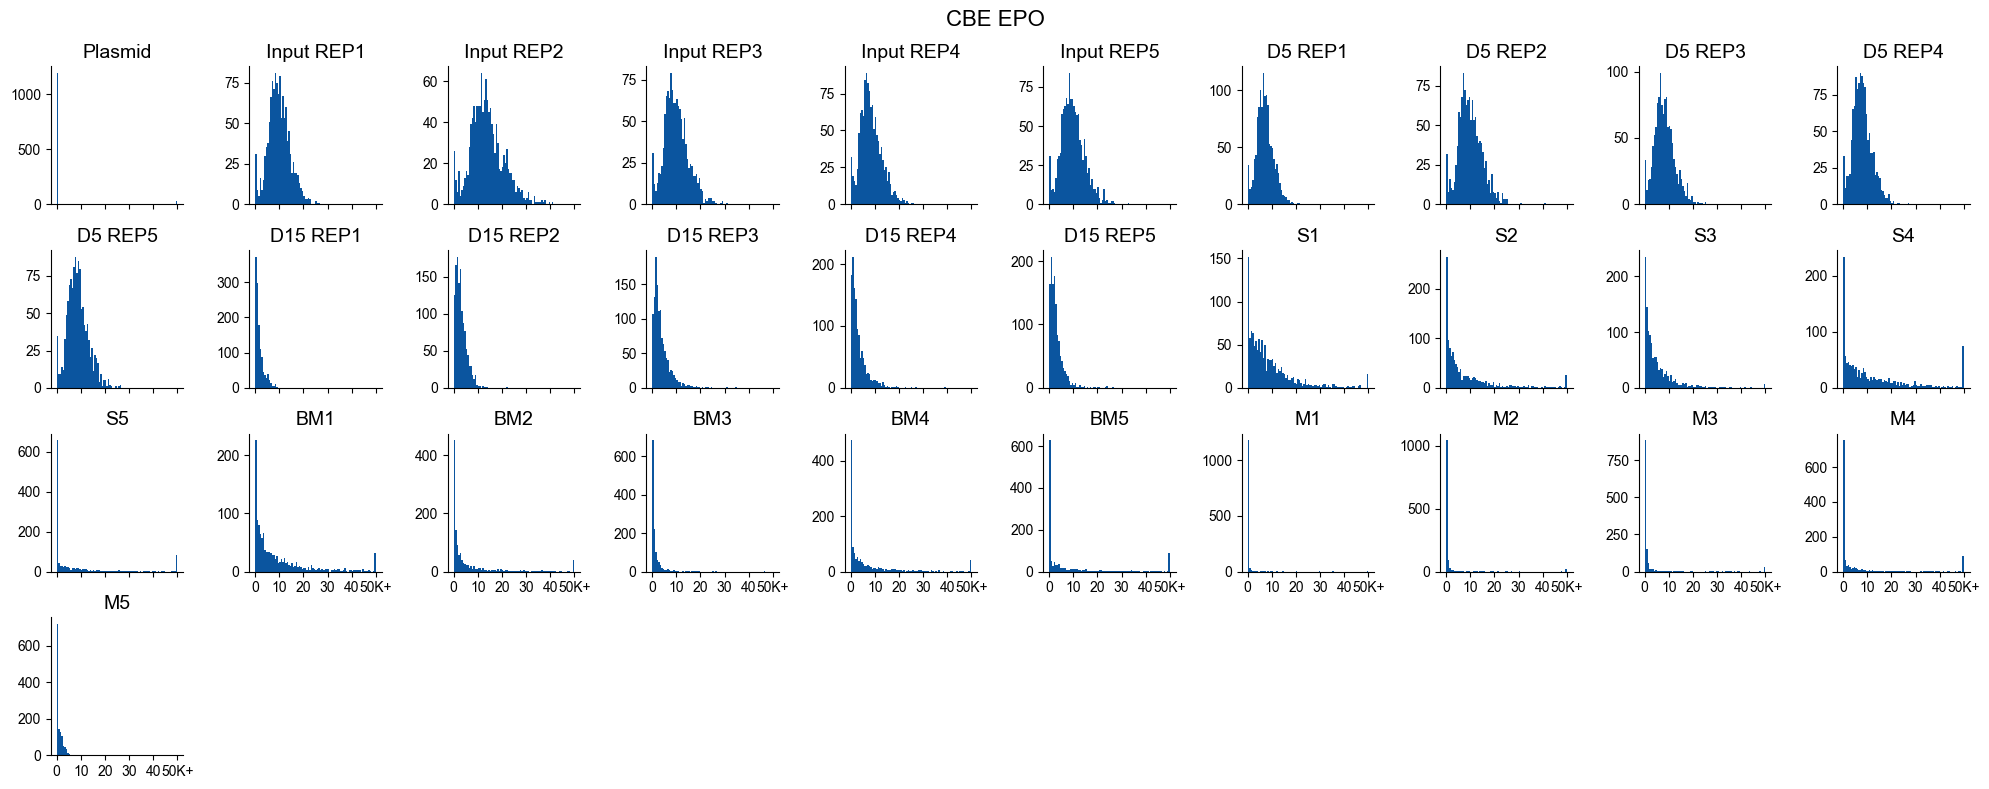

In [65]:
fig, ax = plt.subplots(4,10,figsize=(20,8), sharey=False, sharex=True)

for i in range(4):
    for k in range(10):
        num_samp = (i*10)+k
        #print(num_samp)
        if num_samp<len(CBE_EPO_COUNTS.columns):
            samp = list(CBE_EPO_COUNTS.columns)[num_samp]
            bins=np.linspace(0,50000, 81)
            ax[i][k].hist(np.clip(CBE_EPO_COUNTS[samp], bins[0], bins[-1]), bins=bins,color=blues[5], edgecolor='black', linewidth=0, density=False)
            ax[i][k].set_title(DICT_CBE_EPO[samp], fontsize=14)
            ax[i][k].spines[['top', 'right']].set_visible(False)
            ax[i][k].set_xticks([10000*x for x in [0,1,2,3,4,5]])
            ax[i][k].set_xticklabels([
                '0',
                '10',
                '20',
                '30',
                '40',
                '50K+'
            ])
            #ax.hist[]

for i in range(1,10):
    fig.delaxes(ax[3][i])
    ax[2][i].tick_params(labelbottom=True)

fig.suptitle('CBE EPO', fontsize=16)
fig.tight_layout()
fig.savefig('figures/hist_cbe_epo.pdf')

# Bubble plots of the perc of total sequencing reads assigned to a given gRNA for the top 50 represented guides in each sample

OG extended figure 4 c-d

In [27]:
NORMED_ABE_BC = ABE_BC_COUNTS.copy()
NORMED_ABE_EPO = ABE_EPO_COUNTS.copy()
NORMED_CBE_BC = CBE_BC_COUNTS.copy()
NORMED_CBE_EPO = CBE_EPO_COUNTS.copy()

def normalized_counts(counts):
    for i, val in enumerate(list(counts.columns)):
        sum1 = sum(counts[val])
        counts[val] = 100*(counts[val]/sum1)
    return counts

NORMED_ABE_BC = normalized_counts(NORMED_ABE_BC)
NORMED_ABE_EPO =  normalized_counts(NORMED_ABE_EPO)
NORMED_CBE_BC =  normalized_counts(NORMED_CBE_BC)
NORMED_CBE_EPO =  normalized_counts(NORMED_CBE_EPO)

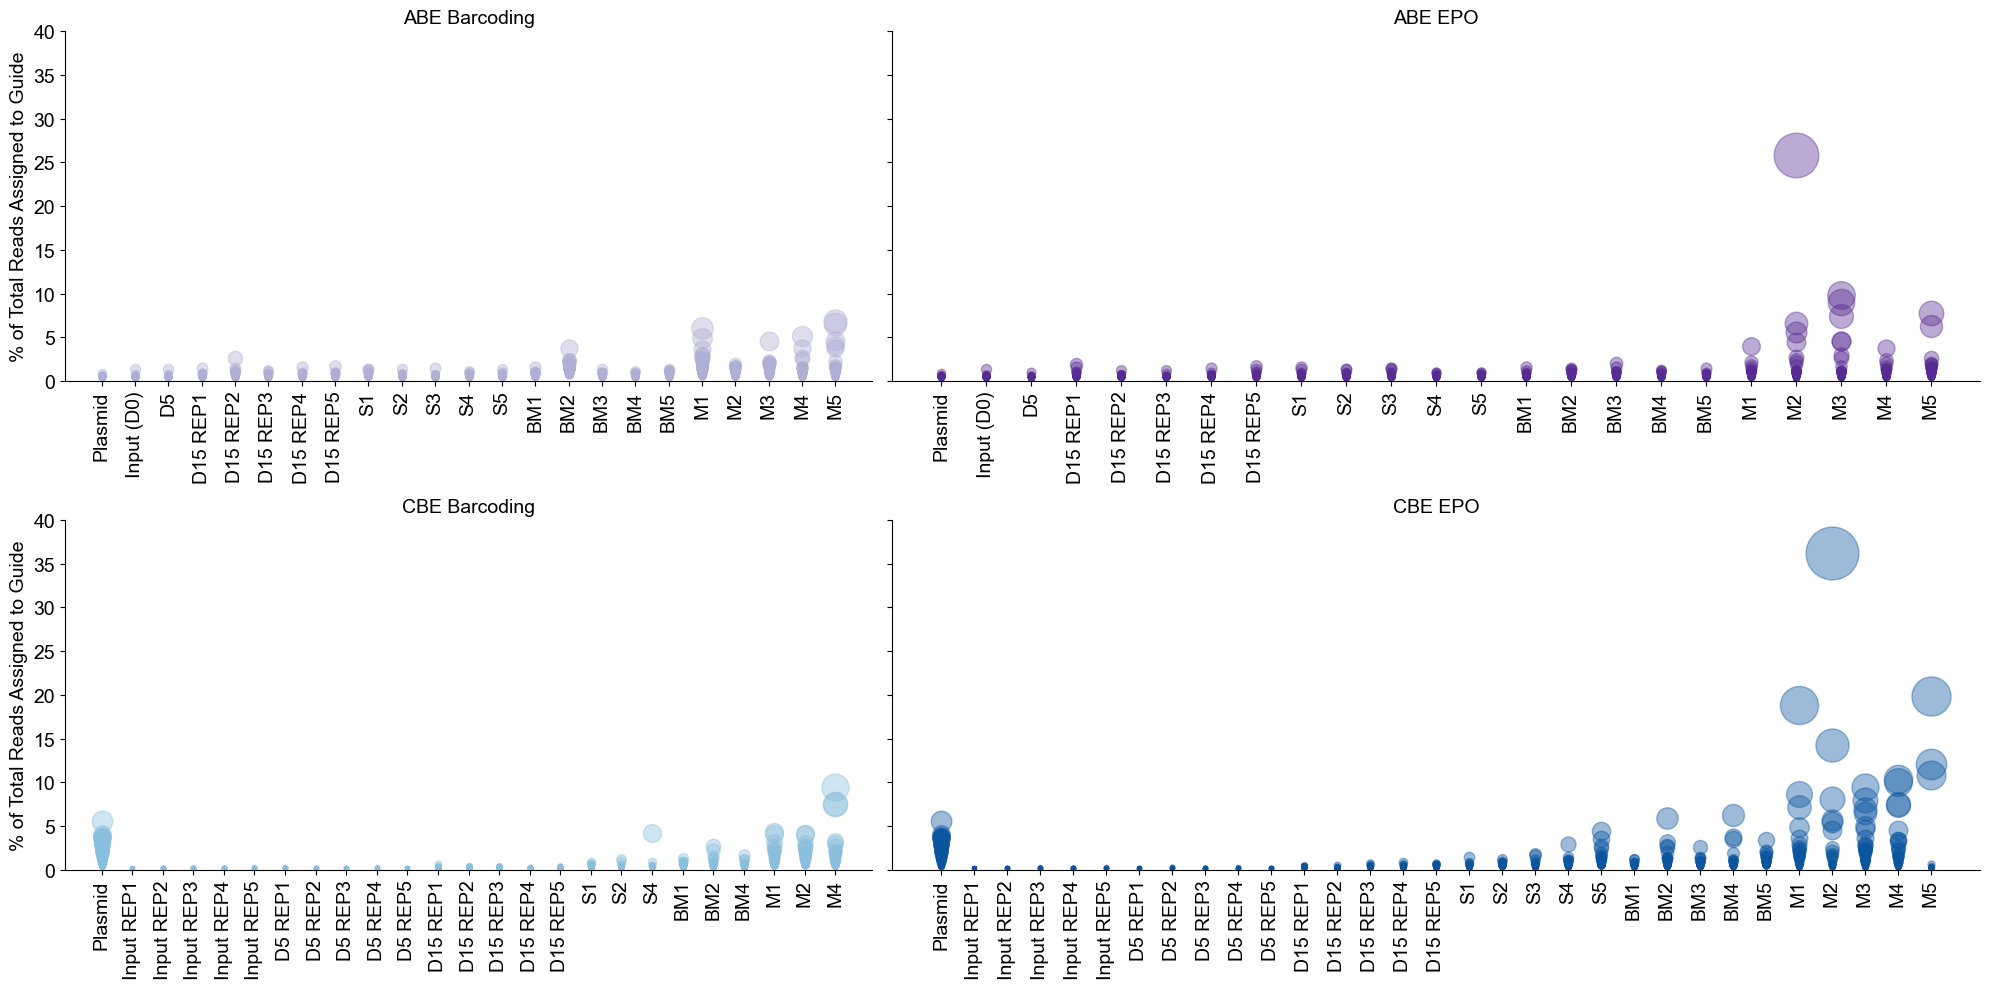

In [66]:
fig, ax = plt.subplots(2,2,figsize=(20,10), sharey=True, width_ratios=[len(NORMED_ABE_BC.columns), len(NORMED_CBE_EPO.columns)])
for i, val in enumerate(list(NORMED_ABE_BC.columns)):
    top_hits = sorted(NORMED_ABE_BC[val])[::-1]
    to_plot = top_hits[:50]
    for j in to_plot:
        ax[0][0].scatter([i], [j], s=j*40, color=purples[2], alpha=.4)

ax[0][0].set_xticks(range(len(NORMED_ABE_BC.columns)));
ax[0][0].set_xticklabels(NAMES_ABE_BC, rotation=90);

for i, val in enumerate(list(NORMED_ABE_EPO.columns)):
    top_hits = sorted(NORMED_ABE_EPO[val])[::-1]
    to_plot = top_hits[:50]
    for j in to_plot:
        ax[0][1].scatter([i], [j], s=j*40, color=purples[5], alpha=.4)

ax[0][1].set_xticks(range(len(NORMED_ABE_EPO.columns)));
ax[0][1].set_xticklabels(NAMES_ABE_EPO, rotation=90);

for i, val in enumerate(list(NORMED_CBE_BC.columns)):
    top_hits = sorted(NORMED_CBE_BC[val])[::-1]
    to_plot = top_hits[:50]
    for j in to_plot:
        ax[1][0].scatter([i], [j], s=j*40, color=blues[2], alpha=.4)

ax[1][0].set_xticks(range(len(NORMED_CBE_BC.columns)));
ax[1][0].set_xticklabels(NAMES_CBE_BC, rotation=90);

for i, val in enumerate(list(NORMED_CBE_EPO.columns)):
    top_hits = sorted(NORMED_CBE_EPO[val])[::-1]
    to_plot = top_hits[:50]
    for j in to_plot:
        ax[1][1].scatter([i], [j], s=j*40, color=blues[5], alpha=.4)

ax[1][1].set_xticks(range(len(NORMED_CBE_EPO.columns)));
ax[1][1].set_xticklabels(NAMES_CBE_EPO, rotation=90);

ax[0][0].set_ylabel('% of Total Reads Assigned to Guide', fontsize=14)
ax[1][0].set_ylabel('% of Total Reads Assigned to Guide', fontsize=14)
ax[0][0].set_title('ABE Barcoding', fontsize=14)
ax[0][1].set_title('ABE EPO', fontsize=14)
ax[1][0].set_title('CBE Barcoding', fontsize=14)
ax[1][1].set_title('CBE EPO', fontsize=14)

ax[0][0].spines[['top', 'right']].set_visible(False)
ax[0][1].spines[['top', 'right']].set_visible(False)
ax[1][0].spines[['top', 'right']].set_visible(False)
ax[1][1].spines[['top', 'right']].set_visible(False)
ax[0][0].tick_params(axis='both', which='major', labelsize=14,)
ax[0][1].tick_params(axis='both', which='major', labelsize=14,)
ax[1][0].tick_params(axis='both', which='major', labelsize=14,)
ax[1][1].tick_params(axis='both', which='major', labelsize=14,)
ax[0][0].set_ylim(0,40)
fig.tight_layout()
fig.savefig('figures/bubbles.pdf')